In [27]:
import pm4py
import os
import pandas as pd
import random

from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.objects.log.obj import EventLog

According to the outputs I got in the first exercise I decided to use Heuristic Miner

In [28]:
class HeuristicProcessDiscovery:
    """
    From the BPMN we discover using Heuristic miner a bpmn model.
    """
    def __init__(self, dependency_threshold=0.5, and_threshold=0.65, loop_two_threshold=0.5):
        self.dep_thresh = dependency_threshold
        self.and_thresh = and_threshold
        self.loop_two_thresh = loop_two_threshold

    def discover(self, log):
        print(f"Mining process model (Dep: {self.dep_thresh}, and: {self.and_thresh})...")
        net, im, fm = pm4py.discover_petri_net_heuristics(
            log,
            dependency_threshold=self.dep_thresh,
            and_threshold=self.and_thresh,
            loop_two_threshold=self.loop_two_thresh
        )
        return net, im, fm

    def evaluate_model(self, log, net, im, fm, sample_size= 1000):
        """
        Fitness, Precision, Generalization, Size, Density like in the first exercise.
        """
        print("Calculating metrics...")
        metrics = {}
        log = pm4py.convert_to_event_log(log)
        log_list = list(log)
        real_size = len(log_list)

        if real_size > sample_size:
            print(f"  Log size ({real_size}) is large. Sampling {sample_size} traces...")
            
            sampled_data = random.sample(log_list, sample_size)
            sampled_log = EventLog(sampled_data)
        else:
            print(f"  Log size ({real_size}) is small enough. Using full log.")
            sampled_log = EventLog(log_list)

        # 1. FITNESS (Token-Based)
        fitness = replay_fitness.apply(sampled_log, net, im, fm, variant=replay_fitness.Variants.TOKEN_BASED)
        metrics['Fitness (Token-Based)'] = fitness['log_fitness']

        # 2. PRECISION
        prec = precision_evaluator.apply(sampled_log, net, im, fm)
        metrics['Precision'] = prec

        # 3. GENERALIZATION
        gen = generalization_evaluator.apply(sampled_log, net, im, fm)
        metrics['Generalization'] = gen

        n_places = len(net.places)
        n_transitions = len(net.transitions)
        n_arcs = len(net.arcs)
        n_nodes = n_places + n_transitions

        # 4. SIZE
        metrics['Size (Nodes)'] = n_nodes
        metrics['Size (Arcs)'] = n_arcs
        metrics['Total Elements'] = n_nodes + n_arcs

        # 5. DENSITY
        max_arcs = 2 * n_places * n_transitions
        metrics['Density'] = n_arcs / max_arcs if max_arcs > 0 else 0.0

        # 6. CONNECTIVITY
        metrics['Avg Connectivity (Degree)'] = n_arcs / n_nodes if n_nodes > 0 else 0.0

        return metrics

Loading Log...
Mining process model (Dep: 0.8, and: 0.65)...
Calculating metrics...
  Log size (31509) is large. Sampling 1000 traces...


replaying log with TBR, completed traces :: 100%|██████████| 731/731 [00:01<00:00, 563.54it/s]
computing precision with alignments, completed variants :: 100%|██████████| 14583/14583 [00:32<00:00, 453.48it/s]
replaying log with TBR, completed traces :: 100%|██████████| 731/731 [00:01<00:00, 548.07it/s]


Model Evaluation Results


,Metric,Value
0,Fitness (Token-Based),0.954695
1,Precision,0.617056
2,Generalization,0.766212
3,Size (Nodes),125.000000
4,Size (Arcs),183.000000
5,Total Elements,308.000000
6,Density,0.025950
7,Avg Connectivity (Degree),1.464000



Visualizing Model:


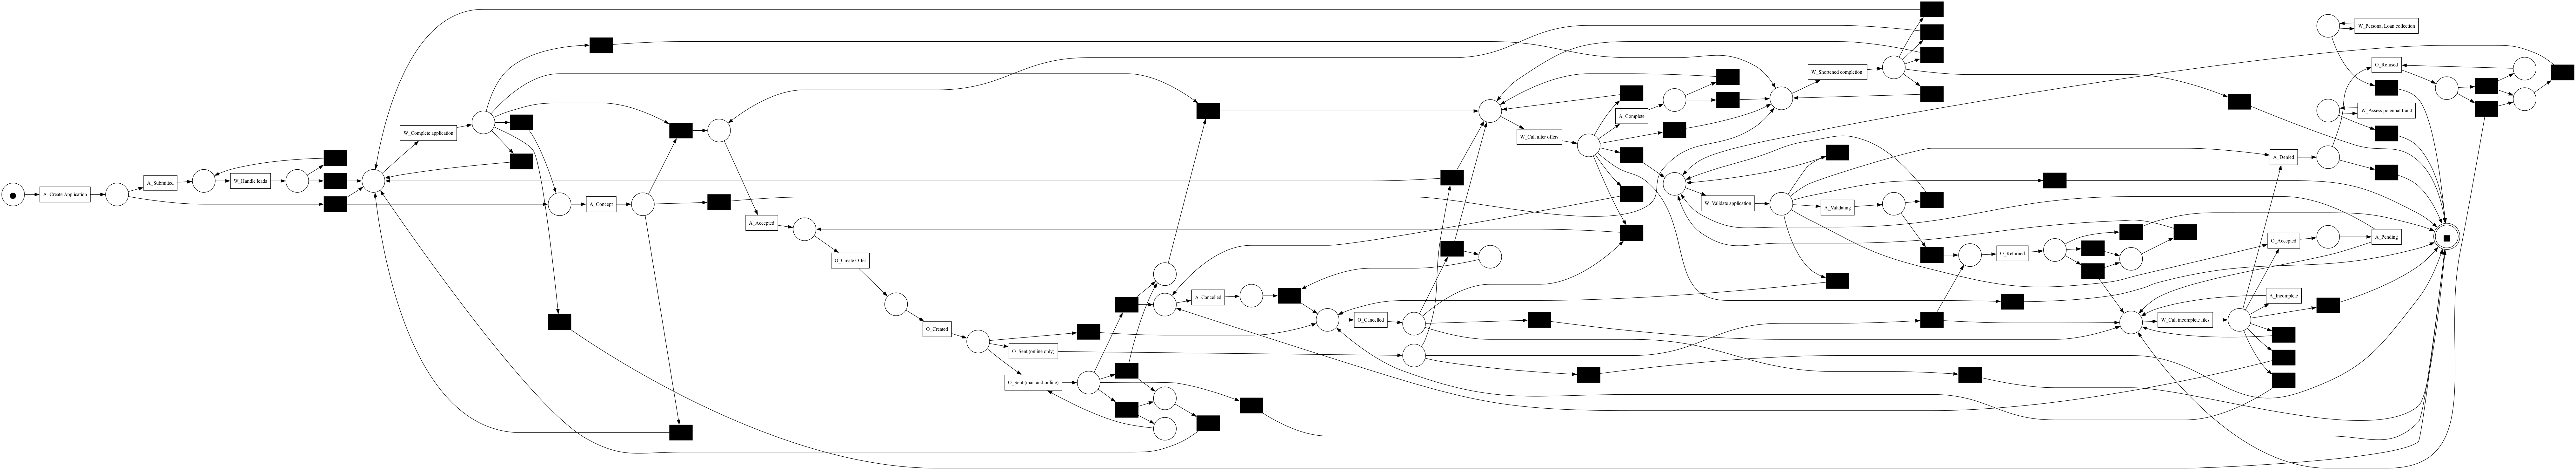

In [29]:

log_path = "/Users/zeynepcetin/bppso-groupwork-1/data/BPI Challenge 2017.xes.gz"

if os.path.exists(log_path):
    print("Loading Log...")
    log = pm4py.read_xes(log_path)
    
    miner = HeuristicProcessDiscovery(
        dependency_threshold=0.8,
        and_threshold=0.65
    )
    
    net, im, fm = miner.discover(log)
    
    results = miner.evaluate_model(log, net, im, fm, sample_size=1000)
    
    print("\nModel Evaluation Results")
    df_results = pd.DataFrame(list(results.items()), columns=['Metric', 'Value'])
    display(df_results)
    

    print("\nVisualizing Model:")
    pm4py.view_petri_net(net, im, fm)
    
else:
    print(f"Error: File not found -> {log_path}")

In [30]:
print("\n Saving..")
output_pnml_path = "discovered_model.pnml"

pm4py.write_pnml(net,im,fm,output_pnml_path)
print(f" Petri Net saved to: {os.path.abspath(output_pnml_path)}")


 Saving..
 Petri Net saved to: /Users/zeynepcetin/bppso-groupwork-1/decisions/discovered_model.pnml
